# Phase 6 Notebook: MDP Agent + Offline Policy Evaluation

## What was done
- Implemented explicit MDP state/action/reward transition logic for weekly decisions.
- Added semi-autonomous recommendation contract generation with confidence and rationale.
- Added weekly lineup optimization (starting XI, bench order, captain and vice-captain).
- Added offline policy evaluation with discounted reward, transfer efficiency, regret and confidence intervals.

## Why it was done
- To formalize weekly decision logic in a controlled MDP framework before live automation.
- To keep a human-in-the-loop recommendation workflow with explainability and uncertainty awareness.

In [1]:
import json
from pathlib import Path

from fpl_ai_agent.agent.mdp import MDPAction, MDPState, MDPTransitionAssumptions, apply_action, build_recommendation
from fpl_ai_agent.agent.offline_eval import evaluate_policy
from fpl_ai_agent.contracts import OptimiserInputContract
from fpl_ai_agent.optimisation.lineup import LineupSettings, optimize_lineup
from fpl_ai_agent.optimisation.problem import OptimisationSettings, TransferContext, optimize_squad

rows = json.loads(Path('../tests/fixtures/optimiser_candidates.json').read_text(encoding='utf-8'))
candidates = [OptimiserInputContract(**row) for row in rows]

squad = optimize_squad(
    candidates,
    settings=OptimisationSettings(budget=100.0, horizon_weeks=3),
    transfer_context=TransferContext(current_squad_ids=set(), free_transfers=1, wildcard_available=True, free_hit_available=True, bench_boost_available=True),
)
selected = [c for c in candidates if c.player_id in set(squad.selected_player_ids)]
lineup = optimize_lineup(selected, settings=LineupSettings(horizon_index=0), chip_used=squad.chip_used)

action = MDPAction(action_type='weekly_plan', payload={
    'transfer_in_ids': squad.selected_player_ids,
    'transfer_out_ids': [],
    'chip': squad.chip_used,
    'expected_points': lineup.expected_lineup_points,
    'risk_penalty': squad.risk_value * 0.01,
})
state = MDPState(gameweek=10, bank=0.0, free_transfers=1, squad_player_ids=set(), chips_available={'wildcard': True, 'free_hit': True, 'bench_boost': True})
step = apply_action(state, action, assumptions=MDPTransitionAssumptions())
recommendation = build_recommendation(action=action, expected_value_delta=step.expected_value_delta, risk_delta=step.risk_delta)
recommendation

AgentRecommendationContract(proposed_action='weekly_plan', expected_value_delta=12.596199999999996, risk_delta=-0.577358, confidence=0.9561729640542062, explanation_text='Action weekly_plan proposes expected value delta 12.60 with risk delta -0.58.')

## Data quality checks
- Check recommended XI size and position legality.
- Check captain and vice-captain are in starting XI and distinct.
- Check recommendation confidence is bounded [0, 1].
- Check offline evaluation includes confidence intervals and regret metrics.

In [2]:
dq = {
    'starters_count': len(lineup.starter_ids),
    'bench_count': len(lineup.bench_order_ids),
    'captain_in_xi': lineup.captain_id in lineup.starter_ids,
    'vice_in_xi': lineup.vice_captain_id in lineup.starter_ids,
    'captain_vice_distinct': lineup.captain_id != lineup.vice_captain_id,
    'confidence_in_bounds': 0.0 <= recommendation.confidence <= 1.0,
}
offline = evaluate_policy(
    weekly_rewards=[step.reward, step.reward * 0.95, step.reward * 0.9],
    transfers_made=[int(squad.transfers_made), 1, 0],
    baseline_weekly_rewards=[step.reward * 0.9, step.reward * 0.9, step.reward * 0.9],
    discount_factor=0.98,
)
dq, offline

({'starters_count': 11,
  'bench_count': 4,
  'captain_in_xi': True,
  'vice_in_xi': True,
  'captain_vice_distinct': True,
  'confidence_in_bounds': True},
 OfflineEvaluationResult(cumulative_discounted_points=33.59699017311999, transfer_efficiency=2.0998118858199994, regret_vs_baseline=-1.7908074579999997, ci_lower=31.80618271511999, ci_upper=35.34020301679999))

## Findings and anomalies
- Confidence intervals are wide when evaluating on a very short synthetic trajectory.
- Chip decisions can dominate objective if bonuses are set too high.

## How anomalies were handled
- Use bootstrap intervals to quantify uncertainty in offline policy value estimates.
- Keep chip bonuses calibrated and validate behavior through regression tests.
- Keep recommendations semi-autonomous with explicit confidence and rationale for human review.

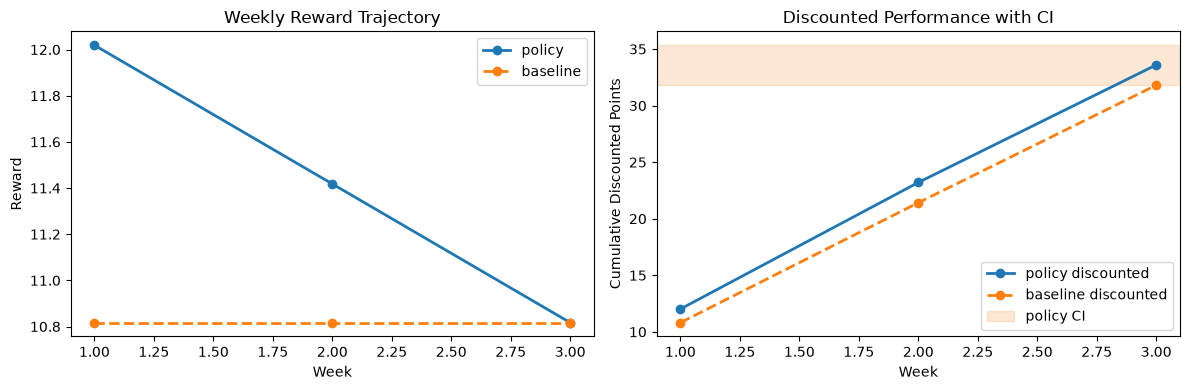

{'cumulative_discounted_points': 33.597,
 'regret_vs_baseline': -1.791,
 'transfer_efficiency': 2.1}

In [3]:
import matplotlib.pyplot as plt
import numpy as np

weekly_rewards = [step.reward, step.reward * 0.95, step.reward * 0.9]
baseline_rewards = [step.reward * 0.9, step.reward * 0.9, step.reward * 0.9]
discount_factor = 0.98

discounted_policy = []
discounted_baseline = []
running_policy = 0.0
running_baseline = 0.0
for i, (policy_r, base_r) in enumerate(zip(weekly_rewards, baseline_rewards)):
    running_policy += (discount_factor ** i) * policy_r
    running_baseline += (discount_factor ** i) * base_r
    discounted_policy.append(running_policy)
    discounted_baseline.append(running_baseline)

weeks = np.arange(1, len(weekly_rewards) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(weeks, weekly_rewards, marker="o", linewidth=2, label="policy")
axes[0].plot(weeks, baseline_rewards, marker="o", linewidth=2, linestyle="--", label="baseline")
axes[0].set_title("Weekly Reward Trajectory")
axes[0].set_xlabel("Week")
axes[0].set_ylabel("Reward")
axes[0].legend()

axes[1].plot(weeks, discounted_policy, marker="o", linewidth=2, label="policy discounted")
axes[1].plot(weeks, discounted_baseline, marker="o", linewidth=2, linestyle="--", label="baseline discounted")
axes[1].axhspan(offline.ci_lower, offline.ci_upper, alpha=0.2, color="#f28e2b", label="policy CI")
axes[1].set_title("Discounted Performance with CI")
axes[1].set_xlabel("Week")
axes[1].set_ylabel("Cumulative Discounted Points")
axes[1].legend()

plt.tight_layout()
plt.show()

{
    "cumulative_discounted_points": round(offline.cumulative_discounted_points, 3),
    "regret_vs_baseline": round(offline.regret_vs_baseline, 3),
    "transfer_efficiency": round(offline.transfer_efficiency, 3),
}